In [1]:
import sys, os
from pathlib import Path

cwd = Path.cwd().resolve()
ROOT = cwd if (cwd / 'src').exists() else cwd.parent
sys.path.insert(0, str(ROOT))
os.chdir(ROOT)

DB_ROOT = ROOT / 'dataset' / 'Database-Master_V2-1'
print(f'ROOT    : {ROOT}')
print(f'DB_ROOT : {DB_ROOT}')


ROOT    : C:\son_spatialisation
DB_ROOT : C:\son_spatialisation\dataset\Database-Master_V2-1


In [2]:
from src.multimodal import MultimodalDataset, AugmentationPipeline, AzimuthalReflection, ImageTransforms
sh_order = 10
pipeline = AugmentationPipeline([
    AzimuthalReflection(sh_order=sh_order, p=0.5),
    ImageTransforms(n_augmentations = 1),
])

ds = MultimodalDataset.build(
    db_root     = 'dataset/Database-Master_V2-1',
    sh_order    = sh_order,
    augmentation = pipeline,
)

# ds.train  → augmentation appliquée aléatoirement (p=0.5)
# ds.val    → jamais d'augmentation
# ds.test   → jamais d'augmentation

ds.save('dataset/preprocessed_dataset.npz')

20 sujets découverts

  D1   ... OK  (121, 129, 2)
  D2   ... OK  (121, 129, 2)
  H10  ... OK  (121, 129, 2)
  H11  ... OK  (121, 129, 2)
  H12  ... OK  (121, 129, 2)
  H13  ... OK  (121, 129, 2)
  H14  ... OK  (121, 129, 2)
  H15  ... OK  (121, 129, 2)
  H16  ... OK  (121, 129, 2)
  H17  ... OK  (121, 129, 2)
  H18  ... OK  (121, 129, 2)
  H19  ... OK  (121, 129, 2)
  H20  ... OK  (121, 129, 2)
  H3   ... OK  (121, 129, 2)
  H4   ... OK  (121, 129, 2)
  H5   ... OK  (121, 129, 2)
  H6   ... OK  (121, 129, 2)
  H7   ... OK  (121, 129, 2)
  H8   ... OK  (121, 129, 2)
  H9   ... OK  (121, 129, 2)
  AzimuthalReflection.expand : 20 → 40 sujets
  ImageTransforms.expand : 40 → 80 sujets (1 copies par sujet)
Dataset après expansion : 80 sujets
Dataset sauvegardé → dataset/preprocessed_dataset.npz


In [3]:
import numpy as np
data = np.load('dataset/preprocessed_dataset.npz', allow_pickle=True)

print( f"Keys in the dataset: {list(data.keys())}")

Keys in the dataset: ['hrtf', 'img_L', 'img_R', 'train_idx', 'val_idx', 'test_idx', 'subject_ids', 'train_mean', 'train_std', 'sh_order']


In [4]:
print(f"Subject ids: {data['subject_ids']}")
print(f"train/test split: {data['train_idx']}, {data['test_idx']} , {data['val_idx']}")

Subject ids: ['D1' 'D2' 'H10' 'H11' 'H12' 'H13' 'H14' 'H15' 'H16' 'H17' 'H18' 'H19'
 'H20' 'H3' 'H4' 'H5' 'H6' 'H7' 'H8' 'H9' 'D1_mirror' 'D2_mirror'
 'H10_mirror' 'H11_mirror' 'H12_mirror' 'H13_mirror' 'H14_mirror'
 'H15_mirror' 'H16_mirror' 'H17_mirror' 'H18_mirror' 'H19_mirror'
 'H20_mirror' 'H3_mirror' 'H4_mirror' 'H5_mirror' 'H6_mirror' 'H7_mirror'
 'H8_mirror' 'H9_mirror' 'D1_aug1' 'D2_aug1' 'H10_aug1' 'H11_aug1'
 'H12_aug1' 'H13_aug1' 'H14_aug1' 'H15_aug1' 'H16_aug1' 'H17_aug1'
 'H18_aug1' 'H19_aug1' 'H20_aug1' 'H3_aug1' 'H4_aug1' 'H5_aug1' 'H6_aug1'
 'H7_aug1' 'H8_aug1' 'H9_aug1' 'D1_mirror_aug1' 'D2_mirror_aug1'
 'H10_mirror_aug1' 'H11_mirror_aug1' 'H12_mirror_aug1' 'H13_mirror_aug1'
 'H14_mirror_aug1' 'H15_mirror_aug1' 'H16_mirror_aug1' 'H17_mirror_aug1'
 'H18_mirror_aug1' 'H19_mirror_aug1' 'H20_mirror_aug1' 'H3_mirror_aug1'
 'H4_mirror_aug1' 'H5_mirror_aug1' 'H6_mirror_aug1' 'H7_mirror_aug1'
 'H8_mirror_aug1' 'H9_mirror_aug1']
train/test split: [47 34 62 42 54 16 39 56 79  7

(121, 129, 2)


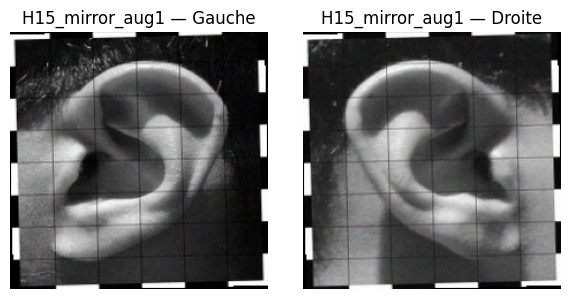

In [6]:
import matplotlib.pyplot as plt

ids     = list(data['subject_ids'])
img_L   = data['img_L']   # [N, 224, 224, 3]
img_R   = data['img_R']
hrtf = data['hrtf']     

# Choisir un sujet par son ID
subject_id = 'H15_mirror_aug1'
idx = ids.index(subject_id)
print( hrtf[idx].shape ) 

fig, axes = plt.subplots(1, 2, figsize=(6, 3))
axes[0].imshow(img_L[idx]); axes[0].set_title(f'{subject_id} — Gauche'); axes[0].axis('off')
axes[1].imshow(img_R[idx]); axes[1].set_title(f'{subject_id} — Droite'); axes[1].axis('off')
plt.tight_layout()
plt.show()
